# Joint Baseline Strategy Diagnostics

Run `scripts/diagnose_joint_baseline_strategies.py` for one or more heuristic/HAPPO strategies, or provide an existing `FILELIST` of diagnostic JSON files to skip rerunning diagnostics. The notebook compares the same core joint performance metrics used for model comparison:

- scout recall: mean and std
- confirmation recall: mean and std
- full-confirm success: rate and binary std
- final confidence: mean and std
- final coverage: mean and std
- scout, confirmation, confidence, and coverage AUC
- time to 100%, 80%, and 50% confirmation recall
- scout-to-confirm latency

Edit the strategy settings in the first code cell. If `FILELIST` is empty, the notebook writes one JSON and one diagnostics plot per strategy, then reads those JSONs. If `FILELIST` is non-empty, it reads those files directly and does not launch diagnostics.


In [31]:
# Baseline comparison configuration. Set CKPT to a HAPPO models directory when you want
# the heuristic baselines to reuse that checkpoint's scenario settings.
MODLABEL = 'uav4_ugv3_1km_256_254_900_hid128_fire_nsurv_min5_max5_obs5'
CKPT = "/Users/aschuetz/Software/capstone/omnisearch/results/harl_runs/wildfire/wildfire_search/happo/uav4_ugv3_1km_256_254_900_hid128_fire_nsurv_min5_max5_obs5"
NSTEPS_PER_EPISODE = 900
SEED_START = 1000
SEED_END = 1049
STRATEGIES = ['ant_colony', 'lawnmower', 'happo']

RUN_DIAGNOSTICS = True
FORCE_RERUN_DIAGNOSTICS = False

# Optional extra CLI arguments for diagnose_joint_baseline_strategies.py.
# Examples: ['--disable-fire'], ['--enable-fire'], ['--n-uavs', '3'].
EXTRA_DIAGNOSTIC_ARGS = []

# Optional: provide existing diagnose_joint_baseline_strategies.py JSON outputs here to skip rerunning diagnostics.
FILELIST = []
FILELIST = [
     'outputs/uav4_ugv3_1sqkm_256_276_900_128_fire_nsurv_min10_max10_obs10_1000_1049.json',
     'outputs/uav4_ugv3_1sqkm_256_276_900_128_fire_nsurv_min10_max10_obs10_ant_colony_1000_1049.json',
     'outputs/uav4_ugv3_1sqkm_256_276_900_128_fire_nsurv_min10_max10_obs10_lawnmower_1000_1049.json',
     'outputs/uav4_ugv3_1sqkm_256_276_900_128_fire_nsurv_min10_max10_obs10_lawnmower_1000_1049.json',
]

# Optional display labels for FILELIST entries. Leave empty to derive labels from JSON metadata / filenames.
LABELS = []
LABELS = ['RL', 'ACO', 'Lawnmower', 'Random Walk']


In [32]:
import json
import shlex
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
if (CWD / 'scripts' / 'diagnose_joint_baseline_strategies.py').is_file():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'scripts' / 'diagnose_joint_baseline_strategies.py').is_file():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = Path('..').resolve()

OUTPUT_DIR = PROJECT_ROOT / 'outputs'
RESULTS_ROOT = PROJECT_ROOT / 'results/harl_runs/wildfire/wildfire_search/happo'

STRATEGY_LABELS = {
    'ant_colony': 'ACO',
    'lawnmower': 'Lawnmower',
    'random_walk': 'Random Walk',
    'random_action': 'Random Action',
    'highest_confidence': 'Highest Confidence',
    'happo': 'HAPPO',
}


def _resolve_checkpoint(ckpt):
    if ckpt is not None:
        ckpt = Path(ckpt).expanduser()
        if not ckpt.is_absolute():
            ckpt = PROJECT_ROOT / ckpt
        if not ckpt.is_dir():
            raise FileNotFoundError(f'Checkpoint directory not found: {ckpt}')
        return ckpt.resolve()

    candidates = sorted((RESULTS_ROOT / MODLABEL).glob('seed-*/models'), key=lambda path: path.stat().st_mtime)
    if not candidates:
        raise FileNotFoundError(
            f'No checkpoint found under {RESULTS_ROOT / MODLABEL}. '
            'Set CKPT to the checkpoint models directory, or keep CKPT=None only when no checkpoint settings are needed.'
        )
    return candidates[-1].resolve()


def _strategy_tag(strategy):
    return str(strategy).strip().lower().replace('-', '_')


def _controller_tag(controller):
    return str(controller).strip().lower().replace('-', '_')


def _diagnostic_output_paths(strategy):
    strategy_tag = _strategy_tag(strategy)
    stem = f'{MODLABEL}_{strategy_tag}_{SEED_START}_{SEED_END}'
    return OUTPUT_DIR / f'{stem}.json', OUTPUT_DIR / f'{stem}.png'


def _resolve_json_file(path):
    path = Path(path).expanduser()
    candidates = [path]
    if not path.is_absolute():
        candidates.extend([PROJECT_ROOT / path, PROJECT_ROOT / 'notebooks' / path])
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    return path.resolve() if path.is_absolute() else (PROJECT_ROOT / path).resolve()


def _strategy_label(strategy):
    return STRATEGY_LABELS.get(_strategy_tag(strategy), str(strategy).replace('_', ' ').title())

if not FILELIST:
    if any(_strategy_tag(strategy) == 'happo' for strategy in STRATEGIES) and CKPT is None:
        raise ValueError('STRATEGIES includes happo, so CKPT must point to a HAPPO models directory.')
    CKPT = _resolve_checkpoint(CKPT) if CKPT is not None else None
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    print('Project root:', PROJECT_ROOT)
    print('Checkpoint settings source:', CKPT if CKPT is not None else 'joint baseline defaults / CLI')
    print('Strategies:', ', '.join(STRATEGIES))


In [33]:
if FILELIST:
    JSON_FILES = [_resolve_json_file(path) for path in FILELIST]
    print('Using provided file list; diagnostics will not be run.')
else:
    JSON_FILES = []
    seeds = [str(seed) for seed in range(SEED_START, SEED_END + 1)]

    for strategy in STRATEGIES:
        json_output, plots_output = _diagnostic_output_paths(strategy)
        if RUN_DIAGNOSTICS and (FORCE_RERUN_DIAGNOSTICS or not json_output.is_file()):
            cmd = [
                sys.executable,
                str(PROJECT_ROOT / 'scripts/diagnose_joint_baseline_strategies.py'),
                '--strategy', str(strategy),
                '--steps', str(NSTEPS_PER_EPISODE),
                '--seeds', *seeds,
                '--json-output', str(json_output),
                '--plots-output', str(plots_output),
            ]
            if CKPT is not None:
                cmd.extend(['--happo-checkpoint', str(CKPT)])
            cmd.extend([str(arg) for arg in EXTRA_DIAGNOSTIC_ARGS])
            print('\nRunning:', shlex.join(cmd))
            log_path = json_output.with_suffix('.log')
            print('This can take a while, please be patient. More details can be found in', log_path)
            with log_path.open('w') as log:
                subprocess.run(
                    cmd,
                    cwd=PROJECT_ROOT,
                    check=True,
                    stdout=log,
                    stderr=subprocess.STDOUT,
                )
        else:
            print('Using existing diagnostics:', json_output.relative_to(PROJECT_ROOT))
        JSON_FILES.append(json_output)

missing = [path for path in JSON_FILES if not path.is_file()]
if missing:
    raise FileNotFoundError('Missing diagnostic JSON files:\n' + '\n'.join(str(path) for path in missing))

print(f'Loaded file list: {len(JSON_FILES)} JSON file(s)')
for path in JSON_FILES:
    print(' -', path.relative_to(PROJECT_ROOT) if path.is_relative_to(PROJECT_ROOT) else path)


Using provided file list; diagnostics will not be run.
Loaded file list: 4 JSON file(s)
 - outputs/uav4_ugv3_1sqkm_256_276_900_128_fire_nsurv_min10_max10_obs10_1000_1049.json
 - outputs/uav4_ugv3_1sqkm_256_276_900_128_fire_nsurv_min10_max10_obs10_ant_colony_1000_1049.json
 - outputs/uav4_ugv3_1sqkm_256_276_900_128_fire_nsurv_min10_max10_obs10_lawnmower_1000_1049.json
 - outputs/uav4_ugv3_1sqkm_256_276_900_128_fire_nsurv_min10_max10_obs10_lawnmower_1000_1049.json


In [34]:
def _summary_value(summary, *keys, default=float('nan')):
    for key in keys:
        if key in summary:
            return summary[key]
    return default


def _payload_scenario(payload):
    scenario = payload.get('scenario')
    if isinstance(scenario, dict) and scenario:
        return scenario
    scenario_kwargs = payload.get('scenario_kwargs')
    if isinstance(scenario_kwargs, dict) and scenario_kwargs:
        return scenario_kwargs
    metadata = payload.get('metadata', {})
    scenario_kwargs = metadata.get('scenario_kwargs') if isinstance(metadata, dict) else None
    return scenario_kwargs if isinstance(scenario_kwargs, dict) else {}


def _strategy_from_payload(path, payload):
    metadata = payload.get('metadata', {})
    strategy = metadata.get('strategy') if isinstance(metadata, dict) else None
    if isinstance(strategy, dict):
        return strategy.get('label') or strategy.get('name') or path.stem
    summary_strategy = payload.get('summary', {}).get('strategy')
    return summary_strategy or path.stem


def _success_rate(summary):
    rate = _summary_value(summary, 'full_confirm_success_rate', 'success_rate')
    if pd.isna(rate):
        percent = _summary_value(summary, 'full_confirm_success_percent')
        rate = percent / 100.0 if not pd.isna(percent) else float('nan')
    return rate


def _success_std(summary, rate):
    if pd.isna(rate):
        return float('nan')
    episodes = _summary_value(summary, 'episodes')
    if pd.isna(episodes) or episodes <= 0:
        return float('nan')
    return float(np.sqrt(max(rate * (1.0 - rate), 0.0)))


def _label_from_payload(path, payload):
    strategy = _strategy_from_payload(path, payload)
    return STRATEGY_LABELS.get(_strategy_tag(strategy), str(strategy).replace('_', ' ').title())


def _finite(values):
    return [float(value) for value in values if isinstance(value, (int, float, np.floating)) and np.isfinite(value)]


def _mean_std(values):
    values = _finite(values)
    if not values:
        return float('nan'), float('nan')
    return float(np.mean(values)), float(np.std(values))


def _episode_steps(row, scenario):
    for key in ('episode_steps', 'max_steps'):
        value = row.get(key)
        if isinstance(value, (int, float)) and value > 0:
            return int(value)
    value = scenario.get('max_steps')
    if isinstance(value, (int, float)) and value > 0:
        return int(value)
    return int(NSTEPS_PER_EPISODE)


def _active_survivor_indices(row):
    explicit = row.get('active_survivor_indices')
    if isinstance(explicit, list):
        return [int(idx) for idx in explicit]
    mask = row.get('active_survivor_mask')
    if isinstance(mask, list):
        return [idx for idx, active in enumerate(mask) if bool(active)]
    steps = row.get('first_scout_steps') or row.get('first_confirm_steps') or []
    count = row.get('active_survivors', row.get('survivors', len(steps)))
    try:
        count = int(count)
    except (TypeError, ValueError):
        count = len(steps)
    return list(range(min(count, len(steps))))


def _auc_from_first_steps(row, scenario, key):
    first_steps = row.get(key)
    if not isinstance(first_steps, list):
        return float('nan')
    steps = max(_episode_steps(row, scenario), 1)
    indices = _active_survivor_indices(row)
    if not indices:
        return 1.0
    total = 0.0
    for idx in indices:
        if idx >= len(first_steps):
            continue
        first_step = first_steps[idx]
        if first_step is None:
            continue
        try:
            first_step = float(first_step)
        except (TypeError, ValueError):
            continue
        if first_step <= 0:
            total += 1.0
        elif first_step <= steps:
            total += (steps - first_step + 1.0) / steps
    return float(total / max(len(indices), 1))


def _row_values(rows, *keys):
    values = []
    for row in rows:
        for key in keys:
            value = row.get(key)
            if isinstance(value, (int, float, np.floating)) and np.isfinite(value):
                values.append(float(value))
                break
    return values


def _summary_or_rows(summary, rows, mean_key, std_key, *row_keys, fallback=None):
    mean = _summary_value(summary, mean_key)
    std = _summary_value(summary, std_key)
    if not pd.isna(mean):
        return float(mean), float(std) if not pd.isna(std) else float('nan')
    values = _row_values(rows, *row_keys)
    if not values and fallback is not None:
        values = [fallback(row) for row in rows]
    return _mean_std(values)


def _threshold_time(summary, threshold_key):
    container = summary.get('time_to_confirm_s', {})
    stats = container.get(threshold_key, {}) if isinstance(container, dict) else {}
    if not isinstance(stats, dict):
        stats = {}
    return {
        'mean': float(stats.get('mean_s', float('nan'))),
        'std': float(stats.get('std_s', float('nan'))),
        'reached_fraction': float(stats.get('reached_fraction', float('nan'))),
        'reached_count': float(stats.get('reached_count', float('nan'))),
    }


def _latency_stats(summary):
    fast = summary.get('fast_metrics', {})
    latency = fast.get('scout_to_confirm_latency_s') if isinstance(fast, dict) else None
    if isinstance(latency, dict):
        mean = latency.get('mean', float('nan'))
        std = latency.get('std', float('nan'))
    else:
        mean = _summary_value(summary, 'mean_scout_to_confirm_latency_s')
        std = _summary_value(summary, 'std_scout_to_confirm_latency_s')
    return float(mean), float(std)


if LABELS and len(LABELS) != len(JSON_FILES):
    raise ValueError(f'LABELS has {len(LABELS)} entries, but JSON_FILES has {len(JSON_FILES)} files')

records = []
for file_index, path in enumerate(JSON_FILES):
    payload = json.loads(path.read_text())
    summary = payload.get('summary', {})
    rows = payload.get('rows', [])
    scenario = _payload_scenario(payload)
    success_rate = _success_rate(summary)
    scout_auc_mean, scout_auc_std = _summary_or_rows(
        summary,
        rows,
        'mean_scout_auc',
        'std_scout_auc',
        'scout_auc',
        fallback=lambda row, scenario=scenario: _auc_from_first_steps(row, scenario, 'first_scout_steps'),
    )
    confirm_auc_mean, confirm_auc_std = _summary_or_rows(
        summary,
        rows,
        'mean_confirm_auc',
        'std_confirm_auc',
        'confirm_auc',
        'confirmation_auc',
        fallback=lambda row, scenario=scenario: _auc_from_first_steps(row, scenario, 'first_confirm_steps'),
    )
    coverage_auc_mean, coverage_auc_std = _summary_or_rows(
        summary,
        rows,
        'mean_coverage_auc',
        'std_coverage_auc',
        'coverage_auc',
    )
    confidence_auc_mean, confidence_auc_std = _summary_or_rows(
        summary,
        rows,
        'mean_confidence_auc',
        'std_confidence_auc',
        'confidence_auc',
    )
    confirm_100 = _threshold_time(summary, 'recall_100')
    confirm_080 = _threshold_time(summary, 'recall_080')
    confirm_050 = _threshold_time(summary, 'recall_050')
    latency_mean, latency_std = _latency_stats(summary)
    records.append({
        'file': str(path),
        'label': str(LABELS[file_index]) if LABELS else _label_from_payload(path, payload),
        'strategy': _strategy_from_payload(path, payload),
        'episodes': _summary_value(summary, 'episodes', default=len(rows) if rows else float('nan')),
        'scout_recall_mean': _summary_value(summary, 'mean_scout_recall'),
        'scout_recall_std': _summary_value(summary, 'std_scout_recall'),
        'confirm_recall_mean': _summary_value(summary, 'mean_confirm_recall'),
        'confirm_recall_std': _summary_value(summary, 'std_confirm_recall'),
        'success_mean': success_rate,
        'success_std': _success_std(summary, success_rate),
        'success_count': _summary_value(summary, 'full_confirm_success_count'),
        'final_confidence_mean': _summary_value(summary, 'mean_final_confidence'),
        'final_confidence_std': _summary_value(summary, 'std_final_confidence'),
        'final_coverage_mean': _summary_value(summary, 'mean_final_coverage_fraction'),
        'final_coverage_std': _summary_value(summary, 'std_final_coverage_fraction'),
        'scout_auc_mean': scout_auc_mean,
        'scout_auc_std': scout_auc_std,
        'confirm_auc_mean': confirm_auc_mean,
        'confirm_auc_std': confirm_auc_std,
        'coverage_auc_mean': coverage_auc_mean,
        'coverage_auc_std': coverage_auc_std,
        'confidence_auc_mean': confidence_auc_mean,
        'confidence_auc_std': confidence_auc_std,
        'confirm_time_100_mean_s': confirm_100['mean'],
        'confirm_time_100_std_s': confirm_100['std'],
        'confirm_time_100_reached_fraction': confirm_100['reached_fraction'],
        'confirm_time_080_mean_s': confirm_080['mean'],
        'confirm_time_080_std_s': confirm_080['std'],
        'confirm_time_080_reached_fraction': confirm_080['reached_fraction'],
        'confirm_time_050_mean_s': confirm_050['mean'],
        'confirm_time_050_std_s': confirm_050['std'],
        'confirm_time_050_reached_fraction': confirm_050['reached_fraction'],
        'scout_to_confirm_latency_mean_s': latency_mean,
        'scout_to_confirm_latency_std_s': latency_std,
    })

metrics = pd.DataFrame.from_records(records)
metrics


,file,label,strategy,episodes,scout_recall_mean,scout_recall_std,confirm_recall_mean,confirm_recall_std,success_mean,success_std,...,confirm_time_100_std_s,confirm_time_100_reached_fraction,confirm_time_080_mean_s,confirm_time_080_std_s,confirm_time_080_reached_fraction,confirm_time_050_mean_s,confirm_time_050_std_s,confirm_time_050_reached_fraction,scout_to_confirm_latency_mean_s,scout_to_confirm_latency_std_s
0,/Users/aschuetz/Software/capstone/omnisearch/o...,RL,uav4_ugv3_1sqkm_256_276_900_128_fire_nsurv_min...,50.0,0.992,0.027129,0.974,0.043863,0.74,0.438634,...,231.615144,0.74,949.92,171.688537,1.0,580.44,130.819136,1.0,409.979466,277.454267
1,/Users/aschuetz/Software/capstone/omnisearch/o...,ACO,ant_colony,50.0,0.994,0.023749,0.948,0.069971,0.60,0.489898,...,215.356542,0.60,1078.52,237.961278,1.0,707.40,124.322967,1.0,443.801688,304.575437
2,/Users/aschuetz/Software/capstone/omnisearch/o...,Lawnmower,lawnmower,50.0,1.000,0.000000,0.956,0.060531,0.62,0.485386,...,191.707721,0.62,1155.32,207.750084,1.0,736.44,141.540264,1.0,435.439331,306.282070
3,/Users/aschuetz/Software/capstone/omnisearch/o...,Random Walk,lawnmower,50.0,1.000,0.000000,0.956,0.060531,0.62,0.485386,...,191.707721,0.62,1155.32,207.750084,1.0,736.44,141.540264,1.0,435.439331,306.282070


## Compact Table

The table below formats each metric as `mean +/- std` for quick comparison. AUC values are time-integrated performance scores. Confirmation timing values are in minutes and are conditional on episodes that reached the requested confirmation recall threshold; the adjacent reached columns show how many episodes made it that far.


In [35]:
def _pm(mean, std, *, digits=3, suffix=''):
    if pd.isna(mean):
        return 'n/a'
    if pd.isna(std):
        return f'{mean:.{digits}f}{suffix}'
    return f'{mean:.{digits}f} +/- {std:.{digits}f}{suffix}'


def _pct(value):
    if pd.isna(value):
        return 'n/a'
    return f'{100.0 * float(value):.0f}%'


compact = pd.DataFrame({
    'label': metrics['label'],
    'episodes': metrics['episodes'].astype('Int64'),
    'scout recall': [
        _pm(mean, std)
        for mean, std in zip(metrics['scout_recall_mean'], metrics['scout_recall_std'])
    ],
    'confirm recall': [
        _pm(mean, std)
        for mean, std in zip(metrics['confirm_recall_mean'], metrics['confirm_recall_std'])
    ],
    'success': [
        _pm(mean, std)
        for mean, std in zip(metrics['success_mean'], metrics['success_std'])
    ],
    'success count': metrics['success_count'].astype('Int64'),
    'final confidence': [
        _pm(mean, std)
        for mean, std in zip(metrics['final_confidence_mean'], metrics['final_confidence_std'])
    ],
    'final coverage': [
        _pm(mean, std)
        for mean, std in zip(metrics['final_coverage_mean'], metrics['final_coverage_std'])
    ],
    'confirm 100% time (min)': [
        _pm(mean, std, digits=1, suffix=' min')
        for mean, std in zip(metrics['confirm_time_100_mean_s'] / 60.0, metrics['confirm_time_100_std_s'] / 60.0)
    ],
    'confirm 100% reached': [_pct(value) for value in metrics['confirm_time_100_reached_fraction']],
    'confirm 80% time (min)': [
        _pm(mean, std, digits=1, suffix=' min')
        for mean, std in zip(metrics['confirm_time_080_mean_s'] / 60.0, metrics['confirm_time_080_std_s'] / 60.0)
    ],
    'confirm 80% reached': [_pct(value) for value in metrics['confirm_time_080_reached_fraction']],
    'confirm 50% time (min)': [
        _pm(mean, std, digits=1, suffix=' min')
        for mean, std in zip(metrics['confirm_time_050_mean_s'] / 60.0, metrics['confirm_time_050_std_s'] / 60.0)
    ],
    'confirm 50% reached': [_pct(value) for value in metrics['confirm_time_050_reached_fraction']],
    'scout-to-confirm latency (min)': [
        _pm(mean, std, digits=1, suffix=' min')
        for mean, std in zip(metrics['scout_to_confirm_latency_mean_s'] / 60.0, metrics['scout_to_confirm_latency_std_s'] / 60.0)
    ],
    'scout AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['scout_auc_mean'], metrics['scout_auc_std'])
    ],
    'confirm AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['confirm_auc_mean'], metrics['confirm_auc_std'])
    ],
    'coverage AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['coverage_auc_mean'], metrics['coverage_auc_std'])
    ],
    'confidence AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['confidence_auc_mean'], metrics['confidence_auc_std'])
    ],
}).set_index('label')

compact


,episodes,scout recall,confirm recall,success,success count,final confidence,final coverage,confirm 100% time (min),confirm 100% reached,confirm 80% time (min),confirm 80% reached,confirm 50% time (min),confirm 50% reached,scout-to-confirm latency (min),scout AUC,confirm AUC,coverage AUC,confidence AUC
label,,,,,,,,,,,,,,,,,,
RL,50,0.992 +/- 0.027,0.974 +/- 0.044,0.740 +/- 0.439,37,0.993 +/- 0.005,0.997 +/- 0.003,22.2 +/- 3.9 min,74%,15.8 +/- 2.9 min,100%,9.7 +/- 2.2 min,100%,6.8 +/- 4.6 min,0.840 +/- 0.051,0.609 +/- 0.064,0.865 +/- 0.009,0.843 +/- 0.009
ACO,50,0.994 +/- 0.024,0.948 +/- 0.070,0.600 +/- 0.490,30,0.994 +/- 0.002,1.000 +/- 0.000,24.6 +/- 3.6 min,60%,18.0 +/- 4.0 min,100%,11.8 +/- 2.1 min,100%,7.4 +/- 5.1 min,0.811 +/- 0.044,0.547 +/- 0.069,0.832 +/- 0.009,0.815 +/- 0.009
Lawnmower,50,1.000 +/- 0.000,0.956 +/- 0.061,0.620 +/- 0.485,31,1.000 +/- 0.000,1.000 +/- 0.000,25.7 +/- 3.2 min,62%,19.3 +/- 3.5 min,100%,12.3 +/- 2.4 min,100%,7.3 +/- 5.1 min,0.785 +/- 0.053,0.527 +/- 0.070,0.806 +/- 0.004,0.792 +/- 0.004
Random Walk,50,1.000 +/- 0.000,0.956 +/- 0.061,0.620 +/- 0.485,31,1.000 +/- 0.000,1.000 +/- 0.000,25.7 +/- 3.2 min,62%,19.3 +/- 3.5 min,100%,12.3 +/- 2.4 min,100%,7.3 +/- 5.1 min,0.785 +/- 0.053,0.527 +/- 0.070,0.806 +/- 0.004,0.792 +/- 0.004


## Plots

The notebook plots the time-integrated AUC metrics first, then a separate confirmation-timing plot. Timing bars are in minutes, so lower is better.


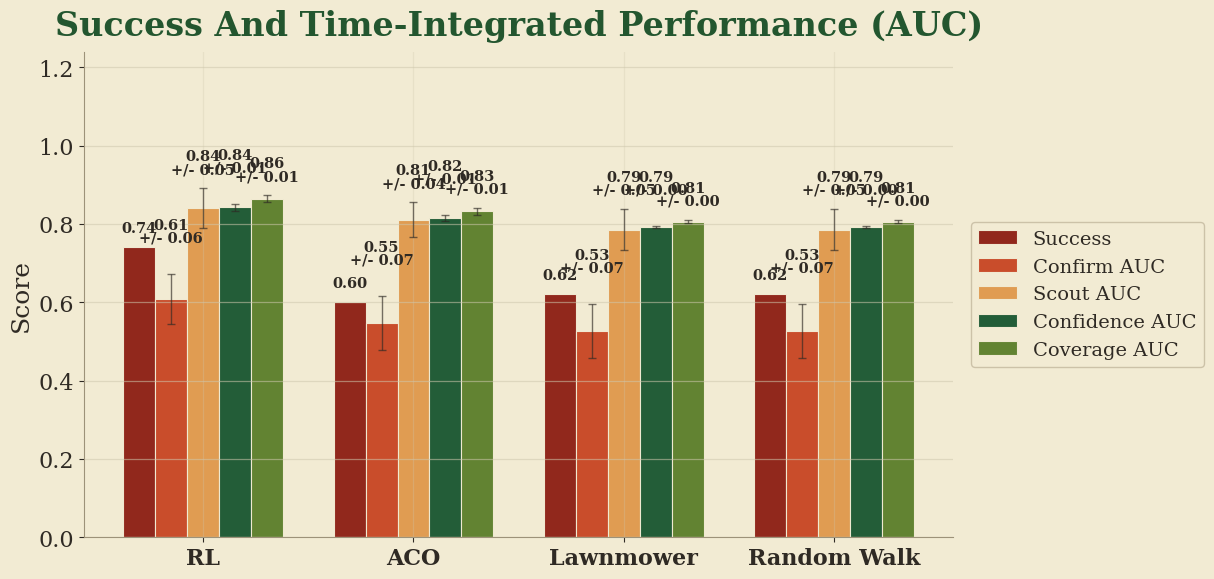

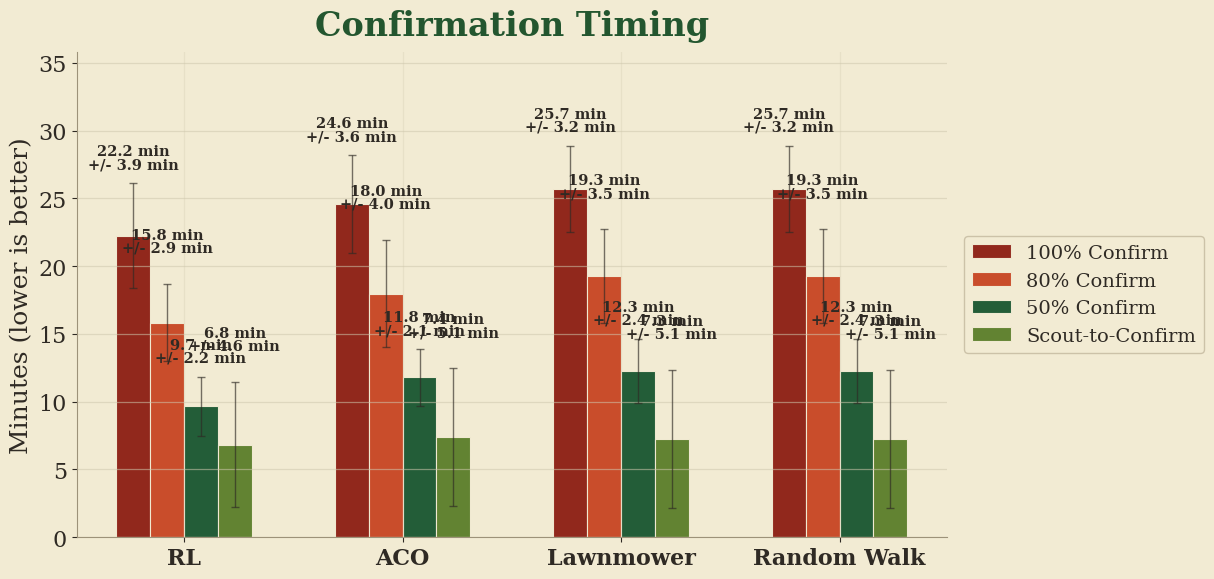

In [36]:
PAPER_BG = '#f2ebd3ff'
GRID_COLOR = '#cfc7ad'
TEXT_GREEN = '#23562f'
TEXT_DARK = '#2f2a24'
AUC_METRIC_SPECS = [
    ('success', 'Success', '#8f2418', 's'),
    ('confirm_auc', 'Confirm AUC', '#c94a27', 's'),
    ('scout_auc', 'Scout AUC', '#e09b4f', 'o'),
    ('confidence_auc', 'Confidence AUC', '#1f5a35', '^'),
    ('coverage_auc', 'Coverage AUC', '#5f812f', 'v'),
]
TIME_METRIC_SPECS = [
    ('confirm_time_100', '100% Confirm', '#8f2418'),
    ('confirm_time_080', '80% Confirm', '#c94a27'),
    ('confirm_time_050', '50% Confirm', '#1f5a35'),
    ('scout_to_confirm_latency', 'Scout-to-Confirm', '#5f812f'),
]

plot_df = metrics.copy().reset_index(drop=True)
for prefix in (
    'confirm_time_100',
    'confirm_time_080',
    'confirm_time_050',
    'scout_to_confirm_latency',
):
    plot_df[f'{prefix}_mean_min'] = pd.to_numeric(plot_df[f'{prefix}_mean_s'], errors='coerce') / 60.0
    plot_df[f'{prefix}_std_min'] = pd.to_numeric(plot_df[f'{prefix}_std_s'], errors='coerce') / 60.0

plt.rcParams.update({
    'figure.facecolor': PAPER_BG,
    'axes.facecolor': PAPER_BG,
    'axes.edgecolor': '#f2ebd3ff',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 24,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'text.color': TEXT_DARK,
    'axes.labelcolor': TEXT_DARK,
    'xtick.color': TEXT_DARK,
    'ytick.color': TEXT_DARK,
    'legend.frameon': True,
    'font.family': 'serif',
})


def _available_specs(specs, df, *, mean_suffix='_mean'):
    keep = []
    for spec in specs:
        prefix = spec[0]
        col = f'{prefix}{mean_suffix}'
        if col in df.columns and pd.to_numeric(df[col], errors='coerce').notna().any():
            keep.append(spec)
    return keep


def _add_bar_labels(ax, bars, std, *, offset_rank=0, suffix='', digits=2, show_error=True):
    y0, y1 = ax.get_ylim()
    yrange = max(y1 - y0, 1e-9)
    for bar, err in zip(bars, std):
        height = bar.get_height()
        if not np.isfinite(height):
            continue
        err = 0.0 if not np.isfinite(err) else float(err)
        label_err = err if show_error else 0.0
        label_y = min(height + label_err + 0.018 * yrange + 0.020 * yrange * (offset_rank % 2), y1 - 0.16 * yrange)
        label_text = f'{height:.{digits}f}{suffix}'
        if show_error:
            label_text = f'{height:.{digits}f}\u00b1{err:.{digits}f}{suffix}'
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            label_y,
            label_text,
            ha='center',
            va='bottom',
            fontsize=11.0,
            fontweight='bold',
            rotation=90,
            rotation_mode='anchor',
            linespacing=0.9,
            color=TEXT_DARK,
        )


def _plot_grouped_bars(ax, df, specs, *, title, ylabel, mean_suffix='_mean', std_suffix='_std', y_limit=None, label_suffix='', label_digits=2):
    specs = _available_specs(specs, df, mean_suffix=mean_suffix)
    if not specs:
        ax.set_axis_off()
        ax.set_title(f'{title} not available', color=TEXT_GREEN, pad=12)
        return
    positions = np.arange(len(df))
    width = min(0.155, 0.76 / max(len(specs), 1))
    offset_units = np.arange(len(specs), dtype=float) - (len(specs) - 1) / 2.0
    series = []
    ymax = 1.0
    for prefix, label, color, *_rest in specs:
        mean = pd.to_numeric(df[f'{prefix}{mean_suffix}'], errors='coerce').to_numpy(dtype=float)
        std = pd.to_numeric(df[f'{prefix}{std_suffix}'], errors='coerce').to_numpy(dtype=float)
        plot_mean = np.where(np.isfinite(mean), mean, 0.0)
        show_error = prefix != 'success'
        plot_std = np.where(np.isfinite(std) & show_error, std, 0.0)
        if len(plot_mean):
            ymax = max(ymax, float(np.nanmax(plot_mean + plot_std)) * 1.45)
        series.append((prefix, label, color, mean, std, plot_mean, plot_std, show_error))
    if y_limit is None:
        ax.set_ylim(0.0, ymax)
    else:
        ax.set_ylim(*y_limit)
    for offset, (_prefix, label, color, mean, std, plot_mean, plot_std, show_error) in enumerate(series):
        bar_x = positions + offset_units[offset] * width
        bars = ax.bar(
            bar_x,
            plot_mean,
            width=width,
            yerr=plot_std,
            capsize=3 if show_error else 0,
            color=color,
            alpha=0.98,
            label=label,
            edgecolor=PAPER_BG,
            linewidth=0.8,
            error_kw={'elinewidth': 1.0, 'alpha': 0.65, 'ecolor': TEXT_DARK},
        )
        _add_bar_labels(ax, bars, std, offset_rank=offset, suffix=label_suffix, digits=label_digits, show_error=show_error)
    labels = df['label'].str.replace(r' \| .*$', '', regex=True).tolist()
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=0, ha='center', fontweight='bold', fontsize=16)
    ax.set_title(title, color=TEXT_GREEN, pad=12)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', color=GRID_COLOR, alpha=0.55, linewidth=0.9)
    ax.grid(axis='x', color=GRID_COLOR, alpha=0.30, linewidth=0.9)
    ax.spines['left'].set_color('#9d9279')
    ax.spines['bottom'].set_color('#9d9279')
    legend = ax.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        title=None,
        fontsize=14,
    )
    legend.get_frame().set_facecolor(PAPER_BG)
    legend.get_frame().set_edgecolor('#c8bea4')
    legend.get_frame().set_alpha(0.90)

fig, ax = plt.subplots(figsize=(max(18, len(plot_df) * 2.1), 6.3), facecolor=PAPER_BG)
_plot_grouped_bars(
    ax,
    plot_df,
    AUC_METRIC_SPECS,
    title='Success And Time-Integrated Performance (AUC)',
    ylabel='Score',
    y_limit=(0.0, 1.35),
    label_digits=2,
)
fig.tight_layout(rect=(0.0, 0.0, 0.82, 1.0))
plt.show()

fig, ax = plt.subplots(figsize=(max(18, len(plot_df) * 2.1), 6.3), facecolor=PAPER_BG)
_plot_grouped_bars(
    ax,
    plot_df,
    TIME_METRIC_SPECS,
    title='Confirmation Timing',
    ylabel='Minutes (lower is better)',
    mean_suffix='_mean_min',
    std_suffix='_std_min',
    label_suffix='',
    label_digits=1,
)
fig.tight_layout(rect=(0.0, 0.0, 0.82, 1.0))
plt.show()
